In [1]:
import pandas as pd
import glob
import os
import ast

file = "all-MCU2.csv"

og_df = pd.read_csv(file)
df = og_df

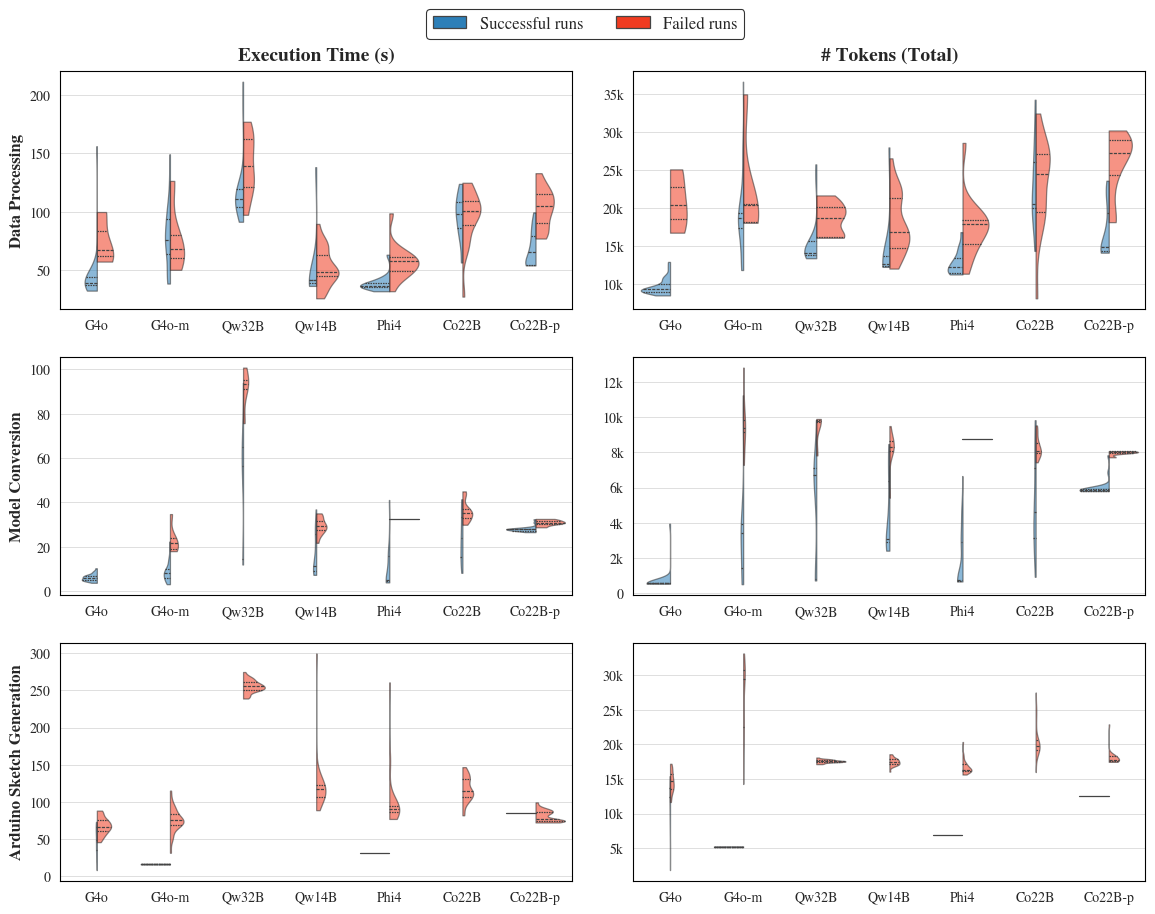

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# ==========================================
# 1. SETUP & DATA
# ==========================================
if 'df' not in locals():
    np.random.seed(42)
    models = ['gpt-4o', 'gpt-4o-mini', 'qwen32', 'qwen14', 'phi4', 'codestral', 'codestral-p']
    processors = ['dp', 'mc', 'sg']
    statuses = ['success', 'failure']

    data = []
    for _ in range(300):
        data.append({
            'processor': np.random.choice(processors),
            'model': np.random.choice(models),
            'status': np.random.choice(statuses, p=[0.8, 0.2]),
            'latency': np.random.lognormal(0, 0.5),
            'total_tokens': np.random.randint(100, 5000)
        })
    df = pd.DataFrame(data)

for col in ['processor', 'model', 'status']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.lower()

# ==========================================
# 2. CONFIGURATION
# ==========================================
model_map = {
    'gpt-4o': 'G4o', 'gpt-4o-mini': 'G4o-m', 'qwen32': 'Qw32B', 'qwen14': 'Qw14B',
    'phi4': 'Phi4', 'codestral': 'Co22B', 'codestral-p': 'Co22B-p'
}
proc_titles = {
    'dp': 'Data Processing', 'mc': 'Model Conversion', 'sg': 'Arduino Sketch Generation'
}

proc_order = ['dp', 'mc', 'sg']
model_order = list(model_map.values())

# Colored palette with better paper readability
palette = {'success': '#2C7FB8', 'failure': '#F03B20'}

df['model_display'] = df['model'].map(model_map)

metrics = [
    {'col': 'latency', 'label': 'Execution Time (s)', 'fmt': None},
    {'col': 'total_tokens', 'label': '# Tokens (Total)', 'fmt': lambda x, p: f'{int(x/1000)}k' if x >= 1000 else f'{int(x)}'}
]

# ==========================================
# 3. PLOTTING (VIOLIN)
#    Transposed layout: rows = tasks, cols = metrics
# ==========================================
sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['STIXGeneral', 'DejaVu Serif', 'Times New Roman']
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['grid.color'] = '#D0D0D0'
plt.rcParams['grid.linewidth'] = 0.6

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 10))
plt.subplots_adjust(top=0.92, hspace=0.20, wspace=0.12)

for row_idx, proc in enumerate(proc_order):
    subset = df[df['processor'] == proc]

    for col_idx, metric in enumerate(metrics):
        ax = axes[row_idx, col_idx]

        if subset.empty:
            ax.set_visible(False)
            continue

        n_collections_before = len(ax.collections)
        sns.violinplot(
            data=subset,
            x='model_display',
            y=metric['col'],
            hue='status',
            hue_order=['success', 'failure'],
            order=model_order,
            split=True,
            inner='quartile',
            cut=0,
            bw_adjust=0.8,
            linewidth=0.9,
            saturation=1.0,
            palette=palette,
            ax=ax
        )

        # Make violin bodies semi-translucent while keeping edges visible.
        for poly in ax.collections[n_collections_before:]:
            if hasattr(poly, 'set_alpha'):
                poly.set_alpha(0.55)
            if hasattr(poly, 'set_edgecolor'):
                poly.set_edgecolor('#2E2E2E')

        if ax.get_legend():
            ax.get_legend().remove()
        ax.set_xlabel('')
        ax.grid(axis='y', alpha=0.8, linestyle='-', linewidth=0.6)

        for spine in ax.spines.values():
            spine.set_linewidth(0.8)

        if row_idx == 0:
            ax.set_title(metric['label'], fontsize=14, weight='bold', pad=8)

        if col_idx == 0:
            ax.set_ylabel(proc_titles.get(proc, proc), fontweight='bold', fontsize=12)
        else:
            ax.set_ylabel('')

        if metric['fmt']:
            ax.yaxis.set_major_formatter(FuncFormatter(metric['fmt']))

handles, labels = axes[0, 0].get_legend_handles_labels()
legend = fig.legend(
    handles[:2],
    ['Successful runs', 'Failed runs'],
    loc='upper center',
    ncol=2,
    bbox_to_anchor=(0.5, 0.99),
    fontsize=12,
    frameon=True
    )
legend.get_frame().set_facecolor('white')
legend.get_frame().set_edgecolor('black')
legend.get_frame().set_linewidth(0.8)

plt.savefig('figs/violin_MCU.pdf', dpi=300, bbox_inches='tight')
plt.show()